In [ ]:
import tensorflow as tf
import os
import cv2
import numpy as np
from tensorflow.keras import datasets, layers, models
import matplotlib.pyplot as plt

In [ ]:
from sklearn.model_selection import train_test_split


train_dir = '/home/kurama/Jazmin/PROY_FACES_MUSIC/feeling_recortado/train'
test_dir = '/home/kurama/Jazmin/PROY_FACES_MUSIC/feeling_recortado/test'


class_names = ['angry', 'fear', 'happy', 'sad', 'surprise']

def load_data(directory):
    X = []
    y = []
    label_map = {class_name: idx for idx, class_name in enumerate(class_names)}
    for label in os.listdir(directory):
        label_dir = os.path.join(directory, label)
        for img_file in os.listdir(label_dir):
            img_path = os.path.join(label_dir, img_file)
            img = cv2.imread(img_path)
            img = cv2.resize(img, (48, 48))
            X.append(img)
            y.append(label_map[label])
    return np.array(X), np.array(y)


x_train, y_train = load_data(train_dir)
x_test, y_test = load_data(test_dir)


print(f"x_train shape: {x_train.shape} - y_train shape: {y_train.shape}")
print(f"x_test shape: {x_test.shape} - y_test shape: {y_test.shape}")

(train_images, train_labels), (test_images, test_labels) =  (x_train, y_train),(x_test, y_test)


train_images, test_images = train_images / 255.0, test_images / 255.0


x_train shape: (23308, 48, 48, 3) - y_train shape: (23308,)
x_test shape: (5834, 48, 48, 3) - y_test shape: (5834,)


In [ ]:
model = models.Sequential()
model.add(layers.Conv2D(48, (3, 3), activation='relu', input_shape=(48, 48, 3)))
model.add(layers.MaxPooling2D((2, 2)))
model.add(layers.Conv2D(48, (3, 3), activation='relu'))
model.add(layers.MaxPooling2D((2, 2)))
model.add(layers.Conv2D(96, (3, 3), activation='relu'))
model.add(layers.Flatten())
model.add(layers.Dense(96, activation='relu'))
model.add(layers.Dense(5))


In [ ]:
model.summary()

Model: "sequential_2"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d_6 (Conv2D)           (None, 46, 46, 48)        1344      
                                                                 
 max_pooling2d_4 (MaxPoolin  (None, 23, 23, 48)        0         
 g2D)                                                            
                                                                 
 conv2d_7 (Conv2D)           (None, 21, 21, 48)        20784     
                                                                 
 max_pooling2d_5 (MaxPoolin  (None, 10, 10, 48)        0         
 g2D)                                                            
                                                                 
 conv2d_8 (Conv2D)           (None, 8, 8, 96)          41568     
                                                                 
 flatten_2 (Flatten)         (None, 6144)             

In [ ]:
model.compile(#optimizer = tf.keras.optimizers.RMSprop(learning_rate=0.0001),
              optimizer='adam',
              loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
              metrics=['accuracy'])

history = model.fit(train_images, train_labels, epochs=10,
                    validation_data=(test_images, test_labels))

In [ ]:
 history = model.fit(train_images, train_labels, epochs=20,
                    validation_data=(test_images, test_labels))



2024-05-08 09:51:41.543586: W tensorflow/tsl/framework/cpu_allocator_impl.cc:83] Allocation of 644419584 exceeds 10% of free system memory.
2024-05-08 09:51:41.894884: W tensorflow/tsl/framework/cpu_allocator_impl.cc:83] Allocation of 644419584 exceeds 10% of free system memory.


Epoch 1/20


2024-05-08 09:51:42.701301: I tensorflow/compiler/xla/stream_executor/cuda/cuda_dnn.cc:442] Loaded cuDNN version 8700
2024-05-08 09:51:42.912260: I tensorflow/compiler/xla/service/service.cc:168] XLA service 0x10b08730 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
2024-05-08 09:51:42.912279: I tensorflow/compiler/xla/service/service.cc:176]   StreamExecutor device (0): NVIDIA RTX A6000, Compute Capability 8.6
2024-05-08 09:51:42.915693: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
2024-05-08 09:51:42.988688: I ./tensorflow/compiler/jit/device_compiler.h:186] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


729/729 [==============================] - 4s 3ms/step - loss: 1.3796 - accuracy: 0.4163 - val_loss: 1.2222 - val_accuracy: 0.4928
Epoch 2/20
729/729 [==============================] - 2s 2ms/step - loss: 1.1479 - accuracy: 0.5303 - val_loss: 1.0977 - val_accuracy: 0.5483
Epoch 3/20
729/729 [==============================] - 2s 2ms/step - loss: 1.0399 - accuracy: 0.5774 - val_loss: 1.0652 - val_accuracy: 0.5744
Epoch 4/20
729/729 [==============================] - 2s 2ms/step - loss: 0.9473 - accuracy: 0.6206 - val_loss: 1.0366 - val_accuracy: 0.5888
Epoch 5/20
729/729 [==============================] - 2s 2ms/step - loss: 0.8666 - accuracy: 0.6552 - val_loss: 1.0233 - val_accuracy: 0.5924
Epoch 6/20
729/729 [==============================] - 2s 2ms/step - loss: 0.7835 - accuracy: 0.6920 - val_loss: 1.0739 - val_accuracy: 0.5828
Epoch 7/20
729/729 [==============================] - 2s 2ms/step - loss: 0.6958 - accuracy: 0.7307 - val_loss: 1.0749 - val_accuracy: 0.5941
Epoch 8/20
729/72

In [ ]:
from tensorflow.keras.models import save_model

save_model(model, 'modelo_emociones')

INFO:tensorflow:Assets written to: modelo_emociones/assets


INFO:tensorflow:Assets written to: modelo_emociones/assets


In [ ]:
from sklearn.metrics import classification_report, confusion_matrix
y_pred = model.predict(x_test)
y_pred_classes = np.argmax(y_pred, axis=1)

print(classification_report(y_test, y_pred_classes))

183/183 [==============================] - 0s 810us/step
              precision    recall  f1-score   support

           0       0.40      0.47      0.43       958
           1       0.33      0.41      0.37      1024
           2       0.73      0.71      0.72      1774
           3       0.44      0.31      0.37      1247
           4       0.61      0.61      0.61       831

    accuracy                           0.52      5834
   macro avg       0.50      0.50      0.50      5834
weighted avg       0.53      0.52      0.52      5834



Matriz de confusión normalizada


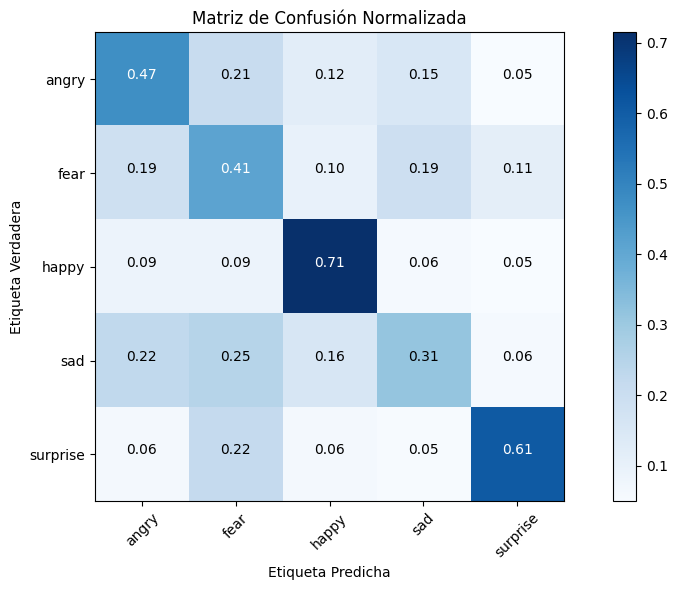

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix
import itertools

conf_matrix = confusion_matrix(y_test, y_pred_classes)

def plot_confusion_matrix(cm, classes,
                          normalize=False,
                          title='Matriz de Confusión',
                          cmap=plt.cm.Blues):

    if normalize:
        cm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
        print("Matriz de confusión normalizada")
    else:
        print('Matriz de confusión sin normalizar')

    plt.imshow(cm, interpolation='nearest', cmap=cmap)
    plt.title(title)
    plt.colorbar()
    tick_marks = np.arange(len(classes))
    plt.xticks(tick_marks, classes, rotation=45)
    plt.yticks(tick_marks, classes)

    fmt = '.2f' if normalize else 'd'
    thresh = cm.max() / 2.
    for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
        plt.text(j, i, format(cm[i, j], fmt),
                 horizontalalignment="center",
                 color="white" if cm[i, j] > thresh else "black")

    plt.ylabel('Etiqueta Verdadera')
    plt.xlabel('Etiqueta Predicha')
    plt.tight_layout()

class_names = ['angry', 'fear', 'happy', 'sad', 'surprise']

# matriz de confusión
plt.figure(figsize=(10, 6))
plot_confusion_matrix(conf_matrix, classes=class_names, normalize=True, title='Matriz de Confusión')
plt.show()


In [2]:
import cv2
import numpy as np
from tensorflow.keras.models import load_model

model = load_model('modelo_emociones')

class_names = ['angry', 'disgust', 'fear', 'happy', 'sad', 'surprise', 'neutral']

#  clasificador de rostros
face_cascade = cv2.CascadeClassifier(cv2.data.haarcascades + 'haarcascade_frontalface_default.xml')

#para predecir emociones y mostrar resultados
def predict_emotion(face_image, x, y, w, h):
    img = cv2.resize(face_image, (48, 48))
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img = img.astype('float32') / 255.0

    # predicción
    prediction = model.predict(np.array([img]))
    predicted_class = np.argmax(prediction)

    # emoción y la confianza
    emotion = class_names[predicted_class]
    confidence = np.max(prediction) * 100

    cv2.putText(frame, f"{emotion}: {confidence:.2f}%", (x, y + h + 20), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (255, 255, 255), 2)

#video
cap = cv2.VideoCapture(0)

while True:
    ret, frame = cap.read()
    if not ret:
        break

    gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)

    # Detecta rostros en la imagen
    faces = face_cascade.detectMultiScale(gray, scaleFactor=1.1, minNeighbors=5, minSize=(30, 30))

    for (x, y, w, h) in faces:

        cv2.rectangle(frame, (x, y), (x+w, y+h), (255, 0, 0), 2)


        face_img = frame[y:y+h, x:x+w]
        predict_emotion(face_img, x, y, w, h)


    cv2.imshow('Video', frame)

    if cv2.waitKey(1) & 0xFF == ord('q'):
        break

cap.release()
cv2.destroyAllWindows()


OSError: No file or directory found at modelo_emociones